In [ ]:
# !pip install git+https://github.com/openai/whisper.git

# import os
# import re
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import pandas as pd
# import librosa
# import whisper
# from torch.utils.data import Dataset, DataLoader
# from sklearn.metrics import mean_absolute_error
# from tqdm import tqdm
# from transformers import DistilBertTokenizer, DistilBertModel

# # ==============================
# # Global Configuration
# # ==============================
# DATA_DIR = "/kaggle/input/"
# CSV_PATH = os.path.join(DATA_DIR, "ser-preprocess/iemocap_regression_metadata.csv")
# DATASET = os.path.join(DATA_DIR, "iemocapfullrelease/IEMOCAP_full_release")
# MFCC_PATH = os.path.join(DATA_DIR, "mfcc-regression")
# MODEL_SAVE_PATH = "/kaggle/working/vad_regressor.pt"

# BATCH_SIZE = 16
# NUM_EPOCHS = 30
# MAX_LEN = 128  # For MFCC
# MAX_TEXT_LEN = 128  # For text tokens
# LR = 0.001
# SR = 16000
# N_MFCC = 13
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# PATIENCE = 3

# # Initialize tokenizer and Whisper (for fallback)
# TOKENIZER = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
# WHISPER_MODEL = whisper.load_model("base").to(DEVICE)

# # ==============================
# # Transcription Parsing
# # ==============================
# def parse_transcriptions(root_dir, sessions):
#     """
#     Parse transcription files from IEMOCAP dialog/transcriptions.
#     Args:
#         root_dir (str): IEMOCAP root directory.
#         sessions (list): List of session names (e.g., ['Session1', ...]).
#     Returns:
#         dict: Mapping of utt_id to transcription text.
#     """
#     transcription_dict = {}
#     pattern = r"(\S+)\s+\[\d+\.\d+-\d+\.\d+\]:\s+(.+)"
    
#     for session in sessions:
#         trans_dir = os.path.join(root_dir, session, "dialog", "transcriptions")
#         if not os.path.exists(trans_dir):
#             print(f"Warning: Transcription directory {trans_dir} does not exist.")
#             continue
        
#         for file in os.listdir(trans_dir):
#             if not file.endswith(".txt"):
#                 continue
#             with open(os.path.join(trans_dir, file), 'r', encoding='utf-8') as f:
#                 for line in f:
#                     match = re.match(pattern, line.strip())
#                     if match:
#                         utt_id, text = match.groups()
#                         transcription_dict[utt_id] = text
    
#     return transcription_dict

# # ==============================
# # Dataset Class
# # ==============================
# class IEMOCAPRegressionDataset(Dataset):
#     def __init__(self, csv_path, root_dir, sessions, max_len=None, max_text_len=None, mean=None, std=None):
#         try:
#             self.data = pd.read_csv(csv_path)
#         except FileNotFoundError:
#             print(f"Error: CSV file not found at {csv_path}")
#             raise
#         self.max_len = max_len
#         self.max_text_len = max_text_len
#         self.mean = mean
#         self.std = std
#         # Load transcriptions
#         self.transcriptions = parse_transcriptions(root_dir, sessions)
        
#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         row = self.data.iloc[idx]
#         utt_id = row['utt_id']
        
#         # Load MFCC
#         try:
#             mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
#         except FileNotFoundError:
#             print(f"Error: MFCC file not found at {row['mfcc_path']}")
#             raise
#         mfcc = torch.tensor(mfcc, dtype=torch.float32)

#         # Normalize MFCCs
#         if self.mean is not None and self.std is not None:
#             mfcc = (mfcc - self.mean) / (self.std + 1e-8)

#         # Compute sequence length
#         seq_len = min(mfcc.shape[0], self.max_len) if self.max_len else mfcc.shape[0]

#         # Pad or truncate MFCC
#         if self.max_len:
#             T = mfcc.shape[0]
#             if T < self.max_len:
#                 pad = torch.zeros((self.max_len - T, mfcc.shape[1]))
#                 mfcc = torch.cat([mfcc, pad], dim=0)
#             else:
#                 mfcc = mfcc[:self.max_len]

#         # Load transcription
#         text = self.transcriptions.get(utt_id, "")
#         if not text:
#             print(f"Warning: No transcription found for {utt_id}. Using empty string.")
        
#         # Tokenize text
#         encoding = TOKENIZER(text, max_length=self.max_text_len, padding='max_length', truncation=True, return_tensors='pt')
#         input_ids = encoding['input_ids'].squeeze(0)
#         attention_mask = encoding['attention_mask'].squeeze(0)

#         target = torch.tensor([row['valence'], row['arousal'], row['dominance']], dtype=torch.float32)
#         return mfcc, input_ids, attention_mask, target, seq_len

#     @staticmethod
#     def compute_statistics(csv_path):
#         try:
#             data = pd.read_csv(csv_path)
#         except FileNotFoundError:
#             print(f"Error: CSV file not found at {csv_path}")
#             raise
#         mfccs = []
#         for _, row in data.iterrows():
#             try:
#                 mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
#                 mfccs.append(mfcc)
#             except FileNotFoundError:
#                 print(f"Error: MFCC file not found at {row['mfcc_path']}")
#                 continue
#         if not mfccs:
#             raise ValueError("No valid MFCC files found")
#         mfccs = np.concatenate(mfccs, axis=0)
#         mean = torch.tensor(mfccs.mean(axis=0), dtype=torch.float32)
#         std = torch.tensor(mfccs.std(axis=0), dtype=torch.float32)
#         return mean, std

# # Custom collation for dual inputs
# def collate_fn(batch):
#     mfccs, input_ids, attention_masks, targets, seq_lens = zip(*batch)
#     mfccs = torch.stack(mfccs)
#     input_ids = torch.stack(input_ids)
#     attention_masks = torch.stack(attention_masks)
#     targets = torch.stack(targets)
#     seq_lens = torch.tensor(seq_lens, dtype=torch.long)
#     return mfccs, input_ids, attention_masks, targets, seq_lens

# # ==============================
# # Model
# # ==============================
# class ScaleLayer(nn.Module):
#     def __init__(self, min_val=1.0, max_val=5.0):
#         super().__init__()
#         self.min_val = min_val
#         self.max_val = max_val

#     def forward(self, x):
#         return (x + 1) * (self.max_val - self.min_val) / 2 + self.min_val

# class DualInputVADRegressor(nn.Module):
#     def __init__(self, speech_input_dim=13, speech_hidden_dim=128, text_hidden_dim=768):
#         super().__init__()
#         # Speech branch (LSTM)
#         self.speech_lstm = nn.LSTM(
#             speech_input_dim,
#             speech_hidden_dim,
#             num_layers=2,
#             batch_first=True,
#             dropout=0.3
#         )
        
#         # Text branch (DistilBERT)
#         self.text_encoder = DistilBertModel.from_pretrained("distilbert-base-uncased")
#         for param in self.text_encoder.parameters():
#             param.requires_grad = False  # Freeze to save memory

#         # Fusion and regression
#         self.fusion = nn.Linear(speech_hidden_dim + text_hidden_dim, 128)
#         self.regressor = nn.Sequential(
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(64, 3),
#             nn.Tanh(),
#             ScaleLayer(min_val=1.0, max_val=5.0)
#         )

#     def forward(self, mfcc, input_ids, attention_mask, seq_lengths):
#         # Speech branch
#         packed_input = torch.nn.utils.rnn.pack_padded_sequence(
#             mfcc, seq_lengths.cpu(), batch_first=True, enforce_sorted=False
#         )
#         _, (hn, _) = self.speech_lstm(packed_input)
#         speech_out = hn[-1]

#         # Text branch
#         text_out = self.text_encoder(input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

#         # Fusion
#         combined = torch.cat([speech_out, text_out], dim=-1)
#         fused = self.fusion(combined)
#         out = self.regressor(fused)
#         return out

# # ==============================
# # Evaluation
# # ==============================
# def evaluate(model, dataloader, device):
#     model.eval()
#     all_preds, all_targets = [], []

#     with torch.no_grad():
#         for mfcc, input_ids, attention_mask, target, seq_len in dataloader:
#             mfcc, input_ids, attention_mask, target = mfcc.to(device), input_ids.to(device), attention_mask.to(device), target.to(device)
#             preds = model(mfcc, input_ids, attention_mask, seq_len)
#             all_preds.extend(preds.cpu().numpy())
#             all_targets.extend(target.cpu().numpy())

#     preds_np = np.array(all_preds)
#     targets_np = np.array(all_targets)
#     mae = mean_absolute_error(targets_np, preds_np)
#     acc = np.mean(np.round(preds_np) == np.round(targets_np))
#     return mae, acc

# # ==============================
# # Training Loop
# # ==============================
# def train_epoch(model, dataloader, criterion, optimizer, device):
#     model.train()
#     total_loss = 0
#     loop = tqdm(dataloader, desc="Training", leave=False)
#     for mfcc, input_ids, attention_mask, target, seq_len in loop:
#         mfcc, input_ids, attention_mask, target = mfcc.to(device), input_ids.to(device), attention_mask.to(device), target.to(device)
#         optimizer.zero_grad()
#         preds = model(mfcc, input_ids, attention_mask, seq_len)
#         loss = criterion(preds, target)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         loop.set_postfix(loss=loss.item())
#     return total_loss / len(dataloader)

# # ==============================
# # Inference Function
# # ==============================
# def extract_mfcc_from_wav(wav_path, sr=16000, n_mfcc=13):
#     try:
#         y, sr = librosa.load(wav_path, sr=sr)
#         mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
#         mfcc = mfcc.T
#         return torch.tensor(mfcc, dtype=torch.float32)
#     except Exception as e:
#         print(f"Error extracting MFCC from {wav_path}: {e}")
#         return None

# def infer(model, csv_path, root_dir, sessions, utterance_ids=None, wav_paths=None, max_len=1024, max_text_len=128, device=DEVICE):
#     model.eval()
#     results = []

#     # Load normalization stats and transcriptions
#     mean, std = IEMOCAPRegressionDataset.compute_statistics(csv_path)
#     transcriptions = parse_transcriptions(root_dir, sessions)
#     data = pd.read_csv(csv_path)

#     # Process input
#     if utterance_ids and wav_paths:
#         print("Error: Provide either utterance_ids or wav_paths, not both.")
#         return results
#     elif not (utterance_ids or wav_paths):
#         print("Error: Must provide utterance_ids or wav_paths.")
#         return results

#     if utterance_ids:
#         data = data[data['utt_id'].isin(utterance_ids)]
#         if data.empty:
#             print(f"Error: No matching utterance IDs found in {csv_path}.")
#             return results
#         inputs = [(row['utt_id'], os.path.join(MFCC_PATH, row['mfcc_path']), None) for _, row in data.iterrows()]
#     else:
#         inputs = [(os.path.basename(wav_path).replace('.wav', ''), None, wav_path) for wav_path in wav_paths]

#     with torch.no_grad():
#         for utt_id, mfcc_path, wav_path in inputs:
#             try:
#                 # Load or compute MFCC
#                 if mfcc_path:
#                     mfcc = np.load(mfcc_path)
#                     mfcc = torch.tensor(mfcc, dtype=torch.float32)
#                 else:
#                     mfcc = extract_mfcc_from_wav(wav_path, sr=SR, n_mfcc=N_MFCC)
#                     if mfcc is None:
#                         continue

#                 # Normalize MFCC
#                 mfcc = (mfcc - mean) / (std + 1e-8)

#                 # Compute sequence length
#                 seq_len = min(mfcc.shape[0], max_len)

#                 # Pad or truncate MFCC
#                 if mfcc.shape[0] < max_len:
#                     pad = torch.zeros((max_len - mfcc.shape[0], mfcc.shape[1]))
#                     mfcc = torch.cat([mfcc, pad], dim=0)
#                 else:
#                     mfcc = mfcc[:max_len]

#                 # Load transcription
#                 transcription = transcriptions.get(utt_id, None)
#                 if transcription is None and wav_path:
#                     result = WHISPER_MODEL.transcribe(wav_path)
#                     transcription = result["text"]
#                 elif transcription is None:
#                     print(f"Warning: No transcription for {utt_id}. Using empty string.")
#                     transcription = ""

#                 # Tokenize text
#                 encoding = TOKENIZER(transcription, max_length=max_text_len, padding='max_length', truncation=True, return_tensors='pt')
#                 input_ids = encoding['input_ids'].squeeze(0)
#                 attention_mask = encoding['attention_mask'].squeeze(0)

#                 # Prepare inputs
#                 mfcc = mfcc.unsqueeze(0).to(device)
#                 input_ids = input_ids.unsqueeze(0).to(device)
#                 attention_mask = attention_mask.unsqueeze(0).to(device)
#                 seq_len = torch.tensor([seq_len], dtype=torch.long)

#                 # Predict VAD
#                 pred = model(mfcc, input_ids, attention_mask, seq_len)
#                 pred = pred.cpu().numpy()[0]

#                 # Collect metadata
#                 metadata = {'utt_id': utt_id, 'valence_pred': pred[0], 'arousal_pred': pred[1], 'dominance_pred': pred[2], 'transcription': transcription}
#                 if mfcc_path:
#                     row = data[data['utt_id'] == utt_id].iloc[0]
#                     metadata.update({
#                         'valence_true': row['valence'],
#                         'arousal_true': row['arousal'],
#                         'dominance_true': row['dominance'],
#                         'emotion': row['emotion'],
#                         'session': row['session']
#                     })

#                 results.append(metadata)
#                 print(f"Predicted for {utt_id}: Valence={pred[0]:.2f}, Arousal={pred[1]:.2f}, Dominance={pred[2]:.2f}")

#             except Exception as e:
#                 print(f"Error processing {utt_id}: {e}")
#                 continue

#     return results

# def main():
#     print("Files in dataset directory:", os.listdir(DATA_DIR))
#     sessions = ["Session1", "Session2", "Session3", "Session4", "Session5"]

#     # Compute MFCC statistics
#     mean, std = IEMOCAPRegressionDataset.compute_statistics(CSV_PATH)

#     # Verify VAD range
#     data = pd.read_csv(CSV_PATH)
#     print("VAD statistics:\n", data[['valence', 'arousal', 'dominance']].describe())

#     # Prepare dataset and data loaders
#     dataset = IEMOCAPRegressionDataset(CSV_PATH, DATASET, sessions, max_len=MAX_LEN, max_text_len=MAX_TEXT_LEN, mean=mean, std=std)
#     test_size = int(0.1 * len(dataset))
#     val_size = int(0.1 * len(dataset))
#     train_size = len(dataset) - val_size - test_size
#     train_set, val_set, test_set = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

#     train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
#     val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)
#     test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)

#     # Train model
#     model = DualInputVADRegressor().to(DEVICE)
#     criterion = nn.MSELoss()
#     optimizer = optim.Adam(model.parameters(), lr=LR)

#     best_mae = float("inf")
#     patience_counter = 0

#     for epoch in range(1, NUM_EPOCHS + 1):
#         print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
#         loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
#         mae, acc = evaluate(model, val_loader, DEVICE)
#         print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | MAE: {mae:.4f} | Rounded Acc: {acc:.4f}")

#         if mae < best_mae:
#             best_mae = mae
#             patience_counter = 0
#             torch.save(model.state_dict(), MODEL_SAVE_PATH)
#             print(f"New best MAE: {mae:.4f}. Model saved.")
#         else:
#             patience_counter += 1
#             print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")
#             if patience_counter >= PATIENCE:
#                 print("Early stopping triggered.")
#                 break

#     # Evaluate on test set
#     print("\nEvaluating on test set...")
#     test_mae, test_acc = evaluate(model, test_loader, DEVICE)
#     print(f"Test MAE: {test_mae:.4f} | Test Rounded Acc: {test_acc:.4f}")
#     print(f"Best Validation MAE: {best_mae:.4f}. Model saved to {MODEL_SAVE_PATH}")

#     # Example inference
#     print("\nRunning inference on sample utterances...")
#     model.load_state_dict(torch.load(MODEL_SAVE_PATH))
#     sample_utt_ids = data['utt_id'].head(3).tolist()
#     results = infer(model, CSV_PATH, DATASET, sessions, utterance_ids=sample_utt_ids, max_len=MAX_LEN, max_text_len=MAX_TEXT_LEN, device=DEVICE)
    
#     print("\nInference Results:")
#     for res in results:
#         print(f"Utterance: {res['utt_id']}")
#         print(f"Transcription: {res['transcription']}")
#         print(f"Predicted: Valence={res['valence_pred']:.2f}, Arousal={res['arousal_pred']:.2f}, Dominance={res['dominance_pred']:.2f}")
#         if 'valence_true' in res:
#             print(f"True: Valence={res['valence_true']:.2f}, Arousal={res['arousal_true']:.2f}, Dominance={res['dominance_true']:.2f}")
#         print()


# if __name__ == "__main__":
#     main()


In [ ]:
data = pd.read_csv(CSV_PATH)
emotions = set(data["emotion"].to_list())
classes = len(emotions)
print(emotions)

data = pd.read_csv(CSV_PATH)
data['emotion'] = data['emotion'].replace('exc', 'hap')
data = data[data['emotion'].isin(['ang', 'hap', 'neu', 'sad'])]
print("Raw emotion distribution:\n", data['emotion'].value_counts())
mapped_emotions = data['emotion'].str.lower().map(LABEL_MAPPING).fillna("other")
print("Mapped emotion distribution:\n", mapped_emotions.value_counts())

data.to_csv("/kaggle/working/" + "iemocap_regression_metadata.csv")



## Attempt 1 on Emotion Detection based on recurrent audio encoding

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm import tqdm

# Configuration
DATA_DIR = "/kaggle/input/"
CSV_PATH = os.path.join(DATA_DIR, "/kaggle/working/iemocap_regression_metadata.csv")
DATASET = os.path.join(DATA_DIR, "iemocapfullrelease/IEMOCAP_full_release")
MFCC_PATH = os.path.join(DATA_DIR, "mfcc-regression")
MODEL_SAVE_PATH = "/kaggle/working/emotion_classifier.pt"

BATCH_SIZE = 16
NUM_EPOCHS = 30
MAX_LEN = 128
N_MFCC = 13
SR = 16000
LR = 0.00001  # Adjusted from 0.1 for LSTM stability
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_CLASSES = [
    "angry", "happy", "sad", "neutral"
]
LABEL_MAPPING = {
    "ang": "angry", "hap": "happy", "sad": "sad", "neu": "neutral"
}

HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

print(f"Using device: {DEVICE}")
print(f"Files in dataset directory: {os.listdir(DATA_DIR)}")

In [ ]:
class IEMOCAPEmotionDataset(Dataset):
    def __init__(self, csv_path, root_dir, sessions, max_len=None, mean=None, std=None):
        try:
            self.data = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at {csv_path}")
            raise
        self.max_len = max_len
        self.mean = mean
        self.std = std
        self.root_dir = root_dir
        self.sessions = sessions
        
        # Encode emotions
        self.emotion_to_idx = {emo: idx for idx, emo in enumerate(EMOTION_CLASSES)}
        self.idx_to_emotion = {idx: emo for emo, idx in self.emotion_to_idx.items()}
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Load MFCC
        try:
            mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
        except FileNotFoundError:
            print(f"Error: MFCC file not found at {row['mfcc_path']}")
            raise
        mfcc = torch.tensor(mfcc, dtype=torch.float32)

        # Normalize MFCCs
        if self.mean is not None and self.std is not None:
            mfcc = (mfcc - self.mean) / (self.std + 1e-8)

        # Compute sequence length
        seq_len = min(mfcc.shape[0], self.max_len) if self.max_len else mfcc.shape[0]

        # Pad or truncate MFCC
        if self.max_len:
            T = mfcc.shape[0]
            if T < self.max_len:
                pad = torch.zeros((self.max_len - T, mfcc.shape[1]))
                mfcc = torch.cat([mfcc, pad], dim=0)
            else:
                mfcc = mfcc[:self.max_len]

        # Emotion target
        emotion = row['emotion'].lower()
        mapped_emotion = LABEL_MAPPING.get(emotion, "other")
        target = torch.tensor(self.emotion_to_idx[mapped_emotion], dtype=torch.long)
        return mfcc, target, seq_len

    @staticmethod
    def compute_statistics(csv_path):
        try:
            data = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at {csv_path}")
            raise
        mfccs = []
        for _, row in data.iterrows():
            try:
                mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
                mfccs.append(mfcc)
            except FileNotFoundError:
                print(f"Error: MFCC file not found at {row['mfcc_path']}")
                continue
        if not mfccs:
            raise ValueError("No valid MFCC files found")
        mfccs = np.concatenate(mfccs, axis=0)
        mean = torch.tensor(mfccs.mean(axis=0), dtype=torch.float32)
        std = torch.tensor(mfccs.std(axis=0), dtype=torch.float32)
        return mean, std

def collate_fn(batch):
    mfccs, targets, seq_lens = zip(*batch)
    mfccs = torch.stack(mfccs)
    targets = torch.stack(targets)
    seq_lens = torch.tensor(seq_lens, dtype=torch.long, device='cpu')  # Ensure CPU tensor
    return mfccs, targets, seq_lens

In [13]:
class LSTMEmotionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm = nn.LayerNorm(N_MFCC)
        
        self.lstm = nn.LSTM(
            input_size=N_MFCC,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0,
            bidirectional=False
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.LayerNorm(128),
            nn.Linear(128, len(EMOTION_CLASSES))
        )
        
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                param.data[HIDDEN_DIM:HIDDEN_DIM*2] = 1  # Forget gate bias

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, seq_lens):
        x = self.layer_norm(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, seq_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed_x)
        return self.classifier(hn[-1])

In [29]:
# Compute statistics
mean, std = IEMOCAPEmotionDataset.compute_statistics(CSV_PATH)
print(f"Mean shape: {mean.shape}, Std shape: {std.shape}")


data = pd.read_csv(CSV_PATH)
data['emotion'] = data['emotion'].replace('exc', 'hap')
data = data[data['emotion'].isin(['ang', 'hap', 'neu', 'sad'])]
print("Raw emotion distribution:\n", data['emotion'].value_counts())
mapped_emotions = data['emotion'].str.lower().map(LABEL_MAPPING).fillna("other")
print("Mapped emotion distribution:\n", mapped_emotions.value_counts())

# Create dataset
sessions = ["Session1", "Session2", "Session3", "Session4", "Session5"]
dataset = IEMOCAPEmotionDataset(
    csv_path=CSV_PATH,
    root_dir=DATASET,
    sessions=sessions,
    max_len=MAX_LEN,
    mean=mean,
    std=std
)

# Split dataset
test_size = int(0.1 * len(dataset))
val_size = int(0.1 * len(dataset))
train_size = len(dataset) - val_size - test_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print(f"Training samples: {len(train_set)}, Validation samples: {len(val_set)}, Test samples: {len(test_set)}")

NameError: name 'IEMOCAPEmotionDataset' is not defined

In [ ]:
# Handle class imbalance
train_indices = train_set.indices
train_data = dataset.data.iloc[train_indices]
class_counts = train_data['emotion'].value_counts().to_dict()
weights = {emo: 1.0 / count for emo, count in class_counts.items()}
sample_weights = [weights[row['emotion']] for _, row in train_data.iterrows()]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# DataLoaders
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print(f"Training batches: {len(train_loader)}, Validation batches: {len(val_loader)}, Test batches: {len(test_loader)}")

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses, val_f1s = [], [], []
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for mfccs, targets, seq_lens in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            mfccs, targets = mfccs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(mfccs, seq_lens)  # seq_lens already on CPU
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_preds, val_targets = [], []
        val_loss = 0
        with torch.no_grad():
            for mfccs, targets, seq_lens in val_loader:
                mfccs, targets = mfccs.to(DEVICE), targets.to(DEVICE)
                outputs = model(mfccs, seq_lens)  # seq_lens on CPU
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())

        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='weighted')
        val_ua = f1_score(val_targets, val_preds, average='macro')
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        val_f1s.append(val_f1)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Val Loss: {val_loss/len(val_loader):.4f}, Val WA: {val_acc:.4f}, Val UA: {val_ua:.4f}, Val F1: {val_f1:.4f}")

        # Early stopping based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            patience_counter = 0
            print(f"New best validation loss: {best_val_loss/len(val_loader):.4f}. Model saved to {MODEL_SAVE_PATH}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')
    
    plt.subplot(1, 2, 2)
    plt.plot(val_f1s, label='Val F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.title('Validation F1')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png')
    plt.show()
    
    return best_val_loss / len(val_loader)

In [ ]:
def evaluate_model(model, data_loader, emotion_classes):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for mfccs, targets_batch, seq_lens in data_loader:
            mfccs = mfccs.to(DEVICE)
            outputs = model(mfccs, seq_lens)  # seq_lens on CPU
            batch_preds = torch.argmax(outputs, dim=1)
            preds.extend(batch_preds.cpu().numpy())
            targets.extend(targets_batch.cpu().numpy())

    wa = accuracy_score(targets, preds)
    ua = f1_score(targets, preds, average='macro')
    f1 = f1_score(targets, preds, average='weighted')
    
    # Confusion matrix
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/confusion_matrix.png')
    plt.show()
    
    return wa, ua, f1

In [ ]:
def extract_mfcc_from_wav(wav_path, sr=16000, n_mfcc=13):
    try:
        y, sr = librosa.load(wav_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.T
        return torch.tensor(mfcc, dtype=torch.float32)
    except Exception as e:
        print(f"Error extracting MFCC from {wav_path}: {e}")
        return None

def infer(model, csv_path, root_dir, sessions, utterance_ids=None, wav_paths=None, max_len=128, n_mfcc=13, mean=None, std=None, emotion_classes=None, device=DEVICE):
    model.eval()
    results = []
    data = pd.read_csv(csv_path)
    idx_to_emotion = {idx: emo for idx, emo in enumerate(emotion_classes)}

    if utterance_ids and wav_paths:
        print("Error: Provide either utterance_ids or wav_paths, not both.")
        return results
    elif not (utterance_ids or wav_paths):
        print("Error: Must provide utterance_ids or wav_paths.")
        return results

    inputs = []
    if utterance_ids:
        data = data[data['utt_id'].isin(utterance_ids)]
        if data.empty:
            print(f"Error: No matching utterance IDs found in {csv_path}.")
            return results
        inputs = [(row['utt_id'], os.path.join(MFCC_PATH, row['mfcc_path']), None, row['session']) for _, row in data.iterrows()]
    else:
        inputs = [(os.path.basename(wav_path).replace('.wav', ''), None, wav_path, None) for wav_path in wav_paths]

    with torch.no_grad():
        for utt_id, mfcc_path, wav_path, session in inputs:
            try:
                # Load or compute MFCC
                if mfcc_path:
                    mfcc = np.load(mfcc_path)
                    mfcc = torch.tensor(mfcc, dtype=torch.float32)
                else:
                    mfcc = extract_mfcc_from_wav(wav_path, sr=SR, n_mfcc=n_mfcc)
                    if mfcc is None:
                        continue

                # Normalize MFCC
                if mean is not None and std is not None:
                    mfcc = (mfcc - mean) / (std + 1e-8)

                # Compute sequence length
                seq_len = min(mfcc.shape[0], max_len)

                # Pad or truncate MFCC
                if mfcc.shape[0] < max_len:
                    pad = torch.zeros((max_len - mfcc.shape[0], mfcc.shape[1]))
                    mfcc = torch.cat([mfcc, pad], dim=0)
                else:
                    mfcc = mfcc[:max_len]

                # Prepare inputs
                mfcc = mfcc.unsqueeze(0).to(device)
                seq_len = torch.tensor([seq_len], dtype=torch.long, device='cpu')  # CPU tensor

                # Predict emotion
                outputs = model(mfcc, seq_len)
                pred_idx = torch.argmax(outputs, dim=1).cpu().numpy()[0]
                pred_emotion = idx_to_emotion[pred_idx]

                # Collect metadata
                metadata = {'utt_id': utt_id, 'emotion_pred': pred_emotion}
                if mfcc_path and session:
                    row = data[data['utt_id'] == utt_id].iloc[0]
                    emotion = row['emotion'].lower()
                    mapped_emotion = LABEL_MAPPING.get(emotion, "other")
                    metadata.update({'emotion': mapped_emotion, 'session': session})

                results.append(metadata)
                print(f"Predicted for {utt_id}: Emotion={pred_emotion}")

            except Exception as e:
                print(f"Error processing {utt_id}: {e}")
                continue

    return results

In [ ]:
# Initialize model
model = LSTMEmotionClassifier().to(DEVICE)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Train
print("Starting training...")
best_val_f1 = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, PATIENCE)
print(f"Best validation F1: {best_val_f1:.4f}")

# Evaluate on test set
print("\nEvaluating on test set...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
wa, ua, f1 = evaluate_model(model, test_loader, EMOTION_CLASSES)
print(f"Test WA: {wa:.4f}, UA: {ua:.4f}, F1: {f1:.4f}")

## As noted from above inference the predicted emotion is capturing tone pitch and frequency well, however giving incorrect results due toprior text context

## Attempt 2: Using Text Based Recurrent Encoding for Emotion Classification

In [6]:
! pip install nltk

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm
import nltk
import requests
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

nltk.download('punkt')

# Configuration
DATA_DIR = "/kaggle/input/"
CSV_PATH = os.path.join(DATA_DIR, "/kaggle/working/iemocap_regression_metadata.csv")
DATASET = os.path.join(DATA_DIR, "iemocapfullrelease/IEMOCAP_full_release")
BATCH_SIZE = 16
NUM_EPOCHS = 30
MAX_LENGTH = 128
LR = 0.01
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTION_CLASSES = ["angry", "happy", "sad", "neutral"]
LABEL_MAPPING = {"ang": "angry", "hap": "happy", "sad": "sad", "neu": "neutral"}
DROPOUT = 0.3
HIDDEN_DIM = 256
NUM_LAYERS = 2
EMBEDDING_DIM = 300
MODEL_SAVE_PATH = "/kaggle/working/text_emotion_classifier.pt"

# Debug: Verify paths
print(f"CSV exists: {os.path.exists(CSV_PATH)}")
print(f"Dataset dir exists: {os.path.exists(DATASET)}")

# GloVe embeddings
def load_glove_embeddings():
    glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
    glove_path = "/kaggle/working/glove.6B.300d.txt"
    
    if not os.path.exists(glove_path):
        print("Downloading GloVe embeddings...")
        response = requests.get(glove_url)
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            z.extractall("/kaggle/working/")
    
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index


  Obtaining dependency information for nltk from https://files.pythonhosted.org/packages/4d/66/7d9e26593edda06e8cb531874633f7c2372279c3b0f46235539fe546df8b/nltk-3.9.1-py3-none-any.whl.metadata
  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Obtaining dependency information for click from https://files.pythonhosted.org/packages/7e/d4/7ebdbd03970677812aac39c869717059dbb71a4cfc033ca6e5221787892c/click-8.1.8-py3-none-any.whl.metadata
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Using cached click-8.1.8-py3-none-any.whl (98 kB)

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
class IEMOCAPTextDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, max_length=128):
        self.data = pd.read_csv(csv_path)
        self.dataset_dir = dataset_dir
        self.max_length = max_length
        self.emotion_to_idx = {emo: idx for idx, emo in enumerate(EMOTION_CLASSES)}
        
        # Load transcripts
        self.transcripts = {}
        for session in ['Session1', 'Session2', 'Session3', 'Session4', 'Session5']:
            trans_dir = os.path.join(dataset_dir, session, 'dialog', 'transcriptions')
            if os.path.exists(trans_dir):
                for trans_file in os.listdir(trans_dir):
                    if trans_file.endswith('.txt'):
                        with open(os.path.join(trans_dir, trans_file), 'r') as f:
                            for line in f:
                                if line.strip():
                                    utt_id = line.split('[')[0].strip()
                                    text = line.split(':')[-1].strip()
                                    self.transcripts[utt_id] = text
        print(f"Number of transcripts loaded: {len(self.transcripts)}")
        
        # Filter data
        print(f"Original data size: {len(self.data)}")
        self.data['mapped_emotion'] = self.data['emotion'].str.lower().map(LABEL_MAPPING)
        self.data = self.data[self.data['mapped_emotion'].isin(EMOTION_CLASSES)]
        self.data = self.data[self.data['utt_id'].isin(self.transcripts.keys())]
        print(f"Filtered data size: {len(self.data)}")
        
        if len(self.data) == 0:
            raise ValueError("Dataset is empty after filtering. Check CSV or transcript files.")
        
        # Build vocabulary
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        word_counts = Counter()
        for text in self.transcripts.values():
            tokens = nltk.word_tokenize(text.lower())
            word_counts.update(tokens)
        
        for word, count in word_counts.items():
            if count >= 3:
                self.word2idx[word] = len(self.word2idx)
        
        # Load GloVe embeddings
        embeddings_index = load_glove_embeddings()
        embedding_matrix = np.zeros((len(self.word2idx), EMBEDDING_DIM))
        for word, idx in self.word2idx.items():
            if word in embeddings_index:
                embedding_matrix[idx] = embeddings_index[word]
            else:
                embedding_matrix[idx] = np.random.normal(0, 0.1, EMBEDDING_DIM)
        self.embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if idx >= len(self.data):
            raise IndexError(f"Index {idx} out of range for dataset of size {len(self.data)}")
        
        row = self.data.iloc[idx]
        utt_id = row['utt_id']
        session = row['session']
        dialogue = utt_id.rsplit('_', 1)[0]
        
        # Get 5 preceding utterances
        dialogue_data = self.data[self.data['utt_id'].str.startswith(dialogue)]
        dialogue_data = dialogue_data.sort_values('utt_id')
        idx_in_dialogue = dialogue_data.index.get_loc(row.name)
        context_utts = dialogue_data.iloc[max(0, idx_in_dialogue-5):idx_in_dialogue]['utt_id'].tolist()
        
        # Build context and target text
        context_texts = [self.transcripts.get(utt, "") for utt in context_utts]
        target_text = self.transcripts.get(utt_id, "")
        context_text = " ".join(context_texts)
        full_text = context_text + " " + target_text
        
        # Tokenize and convert to indices
        tokens = nltk.word_tokenize(full_text.lower())[:self.max_length]
        input_ids = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]
        if len(input_ids) < self.max_length:
            input_ids += [self.word2idx['<PAD>']] * (self.max_length - len(input_ids))
        input_ids = torch.tensor(input_ids, dtype=torch.long)
        
        # Target
        mapped_emotion = row['mapped_emotion']
        target = torch.tensor(self.emotion_to_idx[mapped_emotion], dtype=torch.long)
        
        # Debug
        # if idx < 5:
        #     print(f"Sample {idx}: input_ids.shape={input_ids.shape}, target={target}, utt_id={utt_id}, "
        #           f"context_texts={context_texts[:2]}..., target_text={target_text}")
        
        return input_ids, target, utt_id, context_texts, target_text

# Collate function
def collate_fn(batch):
    input_ids, targets, utt_ids, context_texts, target_texts = zip(*batch)
    input_ids = torch.stack(input_ids)
    targets = torch.stack(targets)
    
    # print(f"Batch shapes: input_ids={input_ids.shape}, targets={targets.shape}, utt_ids_len={len(utt_ids)}")
    
    return input_ids, targets, list(utt_ids), list(context_texts), list(target_texts)


NameError: name 'Dataset' is not defined

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

# Dataset splitting and DataLoader creation
dataset = IEMOCAPTextDataset(CSV_PATH, DATASET, max_length=MAX_LENGTH)
print(f"Total dataset size: {len(dataset)}")

if len(dataset) < 3:
    raise ValueError(f"Dataset too small ({len(dataset)} samples) for 70-15-15 split.")

# Get labels for stratification
labels = [dataset.emotion_to_idx[dataset.data.iloc[idx]['mapped_emotion']] for idx in range(len(dataset))]
label_counts = Counter(labels)
print("Class distribution in full dataset:")
for idx, count in label_counts.items():
    print(f"  {EMOTION_CLASSES[idx]}: {count} ({count/len(dataset)*100:.2f}%)")

# Stratified split
indices = np.arange(len(dataset))
train_indices, temp_indices, train_labels, temp_labels = train_test_split(
    indices,
    labels,
    test_size=0.3,  # 30% for val + test
    stratify=labels,
    random_state=42
)
val_indices, test_indices, val_labels, test_labels = train_test_split(
    temp_indices,
    temp_labels,
    test_size=0.5,  # Split remaining 30% into 15% val, 15% test
    stratify=temp_labels,
    random_state=42
)

# Create Subset datasets
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

# Verify split sizes
train_size, val_size, test_size = len(train_dataset), len(val_dataset), len(test_dataset)
print(f"Dataset sizes: Train={train_size} ({train_size/len(dataset)*100:.2f}%), "
      f"Val={val_size} ({val_size/len(dataset)*100:.2f}%), Test={test_size} ({test_size/len(dataset)*100:.2f}%)")

if train_size == 0 or val_size == 0 or test_size == 0:
    raise ValueError(f"Invalid split: train={train_size}, val={val_size}, test={test_size}")

# Verify class distributions
print("Class distribution in train set:")
train_counts = Counter(train_labels)
for idx, count in train_counts.items():
    print(f"  {EMOTION_CLASSES[idx]}: {count} ({count/train_size*100:.2f}%)")

print("Class distribution in val set:")
val_counts = Counter(val_labels)
for idx, count in val_counts.items():
    print(f"  {EMOTION_CLASSES[idx]}: {count} ({count/val_size*100:.2f}%)")

print("Class distribution in test set:")
test_counts = Counter(test_labels)
for idx, count in test_counts.items():
    print(f"  {EMOTION_CLASSES[idx]}: {count} ({count/test_size*100:.2f}%)")

# Create DataLoaders
train_labels = [dataset.emotion_to_idx[dataset.data.iloc[idx]['mapped_emotion']] for idx in train_indices]
class_counts = np.bincount(train_labels)
class_weights = 1. / (class_counts + 1e-6)
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    collate_fn=collate_fn,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)
print(f"DataLoader sizes: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

Number of transcripts loaded: 10213
Original data size: 5531
Filtered data size: 5531
Total dataset size: 5531
Class distribution in full dataset:
  angry: 1103 (19.94%)
  neutral: 1708 (30.88%)
  sad: 1084 (19.60%)
  happy: 1636 (29.58%)
Dataset sizes: Train=3871 (69.99%), Val=830 (15.01%), Test=830 (15.01%)
Class distribution in train set:
  angry: 772 (19.94%)
  happy: 1145 (29.58%)
  sad: 759 (19.61%)
  neutral: 1195 (30.87%)
Class distribution in val set:
  neutral: 256 (30.84%)
  angry: 166 (20.00%)
  sad: 162 (19.52%)
  happy: 246 (29.64%)
Class distribution in test set:
  sad: 163 (19.64%)
  neutral: 257 (30.96%)
  happy: 245 (29.52%)
  angry: 165 (19.88%)
DataLoader sizes: Train=242, Val=52, Test=52


In [21]:
for batch in train_loader:
    input_ids, targets, utt_ids, context_texts, target_texts = batch
    print(f"First train batch: input_ids.shape={input_ids.shape}, targets.shape={targets.shape}, "
          f"utt_ids={utt_ids[:2]}..., context_texts={context_texts[1][:2]}...")
    break

First train batch: input_ids.shape=torch.Size([16, 128]), targets.shape=torch.Size([16]), utt_ids=['Ses02M_script02_2_F034', 'Ses02M_impro06_M013']..., context_texts=["It's just that- I don't know, it's sort it's sort- of a weird thing you know", "not being able to see anyone again, who knows where they really went, you know. I mean, I guess we can just hope that wherever they are now if it's anywhere that it's better I mean."]...


In [2]:
import torch
import pandas as pd
import os
from tqdm import tqdm
try:
    from IPython.display import Audio, display
    IPYTHON_AVAILABLE = True
except ImportError:
    IPYTHON_AVAILABLE = False
def infer(model, dataset, utterance_ids=None, max_length=128, emotion_classes=None, device=DEVICE):
    model.eval()
    idx_to_emotion = {idx: emo for idx, emo in enumerate(emotion_classes)}
    results = []
    
    # Determine indices to process
    if utterance_ids:
        indices = []
        for i in range(len(dataset)):
            data_idx = dataset.indices[i] if isinstance(dataset, torch.utils.data.Subset) else i
            utt_id = dataset.dataset.data.iloc[data_idx]['utt_id']
            if utt_id in utterance_ids:
                indices.append(i)
    else:
        indices = range(len(dataset))
    
    if not indices:
        print("Warning: No matching utterance_ids found in dataset.")
        return results
    
    with torch.no_grad():
        for idx in tqdm(indices, desc="Running inference"):
            # Get sample from dataset
            input_ids, target, utt_id, context_texts, target_text = dataset[idx]
            
            # Debug: Print sample info
            # print(f"Inferring utt_id={utt_id}, context_texts={context_texts[:2]}..., target_text={target_text}")
            
            # Prepare input
            input_ids = input_ids.unsqueeze(0).to(device)  # [1, max_length]
            
            # Model inference
            outputs = model(input_ids)  # [1, num_classes]
            probs = torch.softmax(outputs, dim=1)
            pred_idx = torch.argmax(probs, dim=1).item()
            pred_emotion = idx_to_emotion[pred_idx]
            pred_prob = probs[0, pred_idx].item()
            
            # True emotion
            true_emotion = idx_to_emotion[target.item()]
            
            # Audio file path
            data_idx = dataset.indices[idx] if isinstance(dataset, torch.utils.data.Subset) else idx
            session = dataset.dataset.data.iloc[data_idx]['session']
            dialogue = utt_id.rsplit('_', 1)[0]
            audio_path = os.path.join(dataset.dataset.dataset_dir, session, 'sentences', 'wav', dialogue, f"{utt_id}.wav")
            audio_exists = os.path.exists(audio_path) if audio_path else False
            
            # Play audio if available
            if audio_exists and IPYTHON_AVAILABLE:
                try:
                    # print(f"Playing audio for {utt_id}: {audio_path}")
                    display(Audio(audio_path))
                except Exception as e:
                    print(f"Failed to play audio for {utt_id}: {e}")
            elif audio_exists:
                print(f"Audio available but playback unsupported (non-Jupyter environment): {audio_path}")
            else:
                print(f"Audio file missing for {utt_id}: {audio_path}")
            
            # Metadata
            metadata = {
                'utt_id': utt_id,
                'audio_path': audio_path,
                'audio_exists': audio_exists,
                'predicted_emotion': pred_emotion,
                'predicted_prob': pred_prob,
                'true_emotion': true_emotion,
                'context_texts': context_texts,
                'target_text': target_text
            }
            results.append(metadata)
            print(f"Predicted for {utt_id}: Emotion={pred_emotion}, Prob={pred_prob:.4f}, True={true_emotion}, Audio5 Audio={audio_path}")
    
    return results

def infer_test_set(model, test_dataset, emotion_classes, device=DEVICE, model_path=MODEL_SAVE_PATH):
    # Load best model
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()
    
    # print(f"Running inference on test set ({len(test_dataset)} samples)")
    results = infer(model, test_dataset, utterance_ids=None, max_length=MAX_LENGTH, 
                    emotion_classes=emotion_classes, device=device)
    
    # Save results to CSV
    output_df = pd.DataFrame(results)
    output_path = '/kaggle/working/test_inference_results.csv'
    output_df.to_csv(output_path, index=False)
    print(f"Test inference results saved to {output_path}")
    
    return results

NameError: name 'DEVICE' is not defined

In [23]:
class LSTMEmotionClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, num_classes, dropout, embedding_matrix):
        super(LSTMEmotionClassifier, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        lstm_out, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        logits = self.fc(hidden)
        return logits

In [24]:
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses, val_f1s = [], [], []
    
    # Initialize learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',           # Minimize validation loss
        factor=0.1,           # Reduce LR by 10x
        patience=1,           # Wait 1 epoch before reducing
        min_lr=1e-7,          # Minimum LR
        verbose=True          # Print LR changes
    )
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for input_ids, targets, _, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            # Debug: Print batch shapes
            # print(f"Train batch: input_ids.shape={input_ids.shape}, targets.shape={targets.shape}")
            
            input_ids, targets = input_ids.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(input_ids)
            
            # Debug: Print output shape
            # print(f"Model output shape: {outputs.shape}")
            
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_preds, val_targets = [], []
        val_loss = 0
        with torch.no_grad():
            for input_ids, targets, _, _, _ in val_loader:
                # Debug: Print batch shapes
                # print(f"Val batch: input_ids.shape={input_ids.shape}, targets.shape={targets.shape}")
                
                input_ids, targets = input_ids.to(DEVICE), targets.to(DEVICE)
                outputs = model(input_ids)
                
                # Debug: Print output shape
                # print(f"Model output shape: {outputs.shape}")
                
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())

        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='weighted')
        val_ua = f1_score(val_targets, val_preds, average='macro')
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        val_f1s.append(val_f1)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Val Loss: {val_loss/len(val_loader):.4f}, Val WA: {val_acc:.4f}, Val UA: {val_ua:.4f}, Val F1: {val_f1:.4f}")
        
        # Step scheduler with validation loss
        scheduler.step(val_loss / len(val_loader))
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current learning rate: {current_lr:.8f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            patience_counter = 0
            print(f"New best validation loss: {best_val_loss/len(val_loader):.4f}. Model saved to {MODEL_SAVE_PATH}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')
    
    plt.subplot(1, 2, 2)
    plt.plot(val_f1s, label='Val F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.title('Validation F1')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png')
    plt.show()
    
    return best_val_loss / len(val_loader)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/30: 100%|██████████| 242/242 [00:16<00:00, 14.92it/s]


Epoch 1/30, Train Loss: 1.3204, Val Loss: 1.1740, Val WA: 0.4542, Val UA: 0.4326, Val F1: 0.4197
Current learning rate: 0.01000000
New best validation loss: 1.1740. Model saved to /kaggle/working/text_emotion_classifier.pt


Epoch 2/30: 100%|██████████| 242/242 [00:16<00:00, 14.87it/s]


Epoch 2/30, Train Loss: 1.0135, Val Loss: 0.9631, Val WA: 0.6000, Val UA: 0.5655, Val F1: 0.5586
Current learning rate: 0.01000000
New best validation loss: 0.9631. Model saved to /kaggle/working/text_emotion_classifier.pt


Epoch 3/30: 100%|██████████| 242/242 [00:16<00:00, 14.89it/s]


...

Epoch 13/30, Train Loss: 0.3273, Val Loss: 0.6526, Val WA: 0.7855, Val UA: 0.7864, Val F1: 0.7852
Current learning rate: 0.00010000
No improvement. Patience: 3/5


Epoch 14/30: 100%|██████████| 242/242 [00:16<00:00, 15.04it/s]


Epoch 14/30, Train Loss: 0.3063, Val Loss: 0.6506, Val WA: 0.7831, Val UA: 0.7843, Val F1: 0.7825
Current learning rate: 0.00001000
No improvement. Patience: 4/5


Epoch 15/30: 100%|██████████| 242/242 [00:16<00:00, 14.89it/s]


Epoch 15/30, Train Loss: 0.3266, Val Loss: 0.6502, Val WA: 0.7831, Val UA: 0.7843, Val F1: 0.7825
Current learning rate: 0.00001000
No improvement. Patience: 5/5
Early stopping triggered.


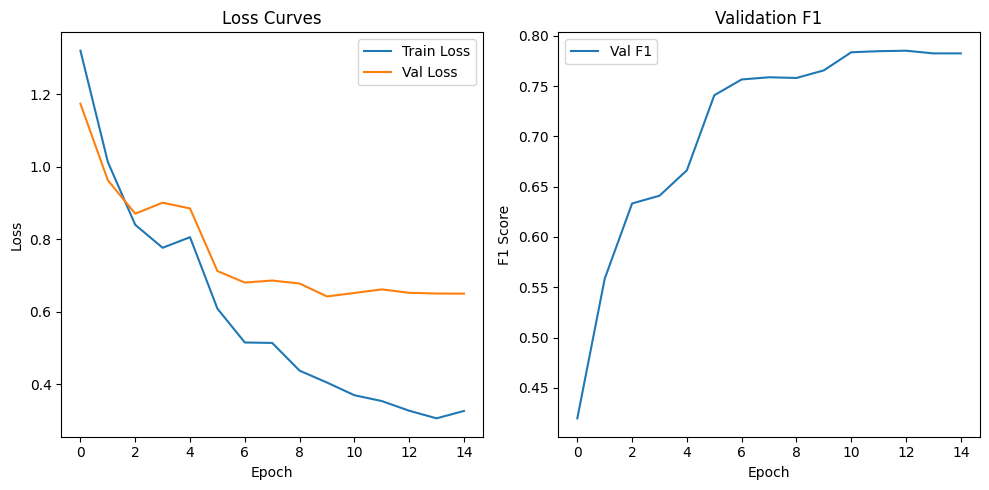

Best validation loss: 0.6425


In [27]:
model = LSTMEmotionClassifier(
    vocab_size=len(dataset.word2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(EMOTION_CLASSES),
    dropout=DROPOUT,
    embedding_matrix=dataset.embedding_matrix
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

best_val_loss = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, PATIENCE)
print(f"Best validation loss: {best_val_loss:.4f}")

In [28]:
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, test_loader, emotion_classes):
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for input_ids, targets, utt_ids, context_texts, target_texts in test_loader:
            # Debug: Print batch shapes and sample metadata
            print(f"Test batch: input_ids.shape={input_ids.shape}, targets.shape={targets.shape}, "
                  f"utt_ids={utt_ids[:2]}..., context_texts={context_texts[0][:2]}...")
            
            input_ids, targets = input_ids.to(DEVICE), targets.to(DEVICE)
            outputs = model(input_ids)
            
            # Debug: Print output shape
            print(f"Model output shape: {outputs.shape}")
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    # Compute metrics
    wa = accuracy_score(all_targets, all_preds)
    ua = f1_score(all_targets, all_preds, average='macro')
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    # Plot confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/confusion_matrix.png')
    plt.show()
    
    print(f"Evaluation completed: WA={wa:.4f}, UA={ua:.4f}, F1={f1:.4f}")
    return wa, ua, f1

In [20]:
model = LSTMEmotionClassifier(
    vocab_size=len(dataset.word2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(EMOTION_CLASSES),
    dropout=DROPOUT,
    embedding_matrix=dataset.embedding_matrix
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)


Evaluating on test set...
Test batch: input_ids.shape=torch.Size([16, 128]), targets.shape=torch.Size([16]), utt_ids=['Ses05M_script01_3_F010', 'Ses01F_script03_2_F031']..., context_texts=["It's all right.  It's a good thing.  It's lovely here.  The air is sweet.", 'Well, your mother, first of all, pretty much told me to leave.']...
Model output shape: torch.Size([16, 4])
Test batch: input_ids.shape=torch.Size([16, 128]), targets.shape=torch.Size([16]), utt_ids=['Ses01M_script02_2_M003', 'Ses02F_impro01_M002']..., context_texts=["I'm beginning to think you might be right.  I think this might be the spot after all.", "Augie, I'm sorry."]...
Model output shape: torch.Size([16, 4])


/tmp/ipykernel_31/1419257140.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_PATH))


Test batch: input_ids.shape=torch.Size([16, 128]), targets.shape=torch.Size([16]), utt_ids=['Ses02M_impro01_F006', 'Ses04F_script03_2_M035']..., context_texts=['Sure, um', 'do you have two forms of ID with you?']...
Model output shape: torch.Size([16, 4])
Test batch: input_ids.shape=torch.Size([16, 128]), targets.shape=torch.Size([16]), utt_ids=['Ses05F_script01_3_M033', 'Ses04F_impro04_F031']..., context_texts=["for instance, there's this one time.  It had been raining for several days.  And this kid came up to me and gave me his last pair of dry socks. you know, He just put them in my pocket.", "I know that- that's not a big thing, but it's just the kind of guys I had. They didn't die. They- They killed themselves for each other."]...
Model output shape: torch.Size([16, 4])
Test batch: input_ids.shape=torch.Size([16, 128]), targets.shape=torch.Size([16]), utt_ids=['Ses02M_script02_2_F018', 'Ses04F_script03_2_F031']..., context_texts=["I mean I feel like my whole life is going to be s

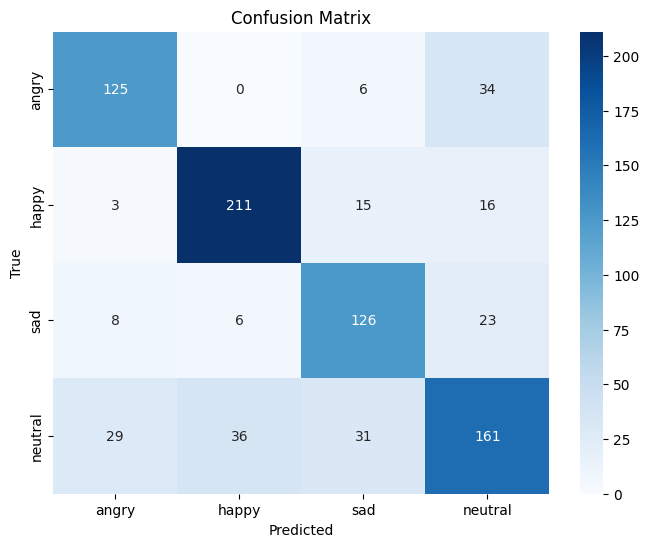

Evaluation completed: WA=0.7506, UA=0.7499, F1=0.7489
Test WA: 0.7506, UA: 0.7499, F1: 0.7489


In [29]:
print("\nEvaluating on test set...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
wa, ua, f1 = evaluate_model(model, test_loader, EMOTION_CLASSES)
print(f"Test WA: {wa:.4f}, UA: {ua:.4f}, F1: {f1:.4f}")

# Infer on test set
# print("\nRunning test set inference with audio paths...")
# test_results = infer_test_set(model, test_dataset[:5], EMOTION_CLASSES, device=DEVICE)
# for result in test_results[:5]:  # Print first 5 for brevity
#     print(result)

In [ ]:
model = LSTMEmotionClassifier(
    vocab_size=len(dataset.word2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(EMOTION_CLASSES),
    dropout=DROPOUT,
    embedding_matrix=dataset.embedding_matrix
).to(DEVICE)

model.load_state_dict(torch.load("text_emotion_classifier.pt"))

model.eval()




NameError: name 'LSTMEmotionClassifier' is not defined

In [ ]:
idx = 0  # First test sample
result = infer(model, test_dataset, idx, max_length=MAX_LENGTH, emotion_classes=EMOTION_CLASSES, device=DEVICE)
print(result)